<a href="https://colab.research.google.com/github/lcbjrrr/algojust/blob/main/Pmpt03_statsMiss_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Statistical Misinterpretation

- **Statistical Misinterpretation**: Misinterpreting results happens when conclusions don’t align with proper statistical analysis, leading to misleading findings. Common issues include assuming correlation means causation, cherry-picking data, or ignoring confounding factors. This can distort research outcomes and impact decision-making. Want to refine it further.
*The data used herein is for illustrative purposes only and does not reflect actual real-world data*.

Download: [Covid-Cytokine.csv](https://raw.githubusercontent.com/lcbjrrr/algojust/refs/heads/main/Covid%20-%20Cytokine.csv)



> Read the 'Covid - Cytokine.csv' file and show the dataframe.

In [2]:
import pandas as pd

df_cytokine = pd.read_csv('Covid - Cytokine.csv')
df_cytokine

,PREmRNA,POSTmRNA,PlacebomRNA,PREVector,POSTVector,PlaceboVector,PREProtein,POSTProtein,PlaceboProtein,PREInactivated,POSTInactivated,PlaceboInactivated,PreDNA,PostDNA,PlaceboDNA
0,40,660,0,40,330.0,0,40,220,0,22,88,0,5,11,0
1,40,150,1,40,75.0,1,40,50,1,33,99,1,11,11,1
2,10,30,1,10,15.0,1,10,10,1,22,88,1,22,22,1
3,20,60,1,20,30.0,1,20,20,1,11,111,1,6,5,1
4,11,45,0,11,22.5,0,11,15,0,22,122,0,7,12,0
5,22,999,0,22,499.5,0,22,333,0,33,133,0,8,13,0
6,5,999,0,5,499.5,0,5,333,0,30,120,0,9,12,0
7,6,999,0,6,499.5,0,6,333,0,20,130,0,11,22,0
8,9,1332,0,9,666.0,0,9,444,0,20,90,0,22,24,0
9,9,1332,0,9,666.0,0,9,444,0,11,99,0,23,26,0


#### Are any of the vaccines effective? Let's take the DNA based one as an initial exemple...



> For the DNA vaccine, filter out the placebo ones (column PlaceboDNA
!=1)

In [3]:
df_dna_vaccine = df_cytokine[df_cytokine['PlaceboDNA'] != 1]
df_dna_vaccine

,PREmRNA,POSTmRNA,PlacebomRNA,PREVector,POSTVector,PlaceboVector,PREProtein,POSTProtein,PlaceboProtein,PREInactivated,POSTInactivated,PlaceboInactivated,PreDNA,PostDNA,PlaceboDNA
0,40,660,0,40,330.0,0,40,220,0,22,88,0,5,11,0
4,11,45,0,11,22.5,0,11,15,0,22,122,0,7,12,0
5,22,999,0,22,499.5,0,22,333,0,33,133,0,8,13,0
6,5,999,0,5,499.5,0,5,333,0,30,120,0,9,12,0
7,6,999,0,6,499.5,0,6,333,0,20,130,0,11,22,0
8,9,1332,0,9,666.0,0,9,444,0,20,90,0,22,24,0
9,9,1332,0,9,666.0,0,9,444,0,11,99,0,23,26,0
10,8,1665,0,8,832.5,0,8,555,0,12,90,0,29,33,0
14,40,660,0,40,330.0,0,40,220,0,22,88,0,5,11,0
18,11,45,0,11,22.5,0,11,15,0,22,122,0,7,12,0


> With the filtered DNA vaccine records, caculate the average measurements of the pre and post effects, and show it in a bar chart


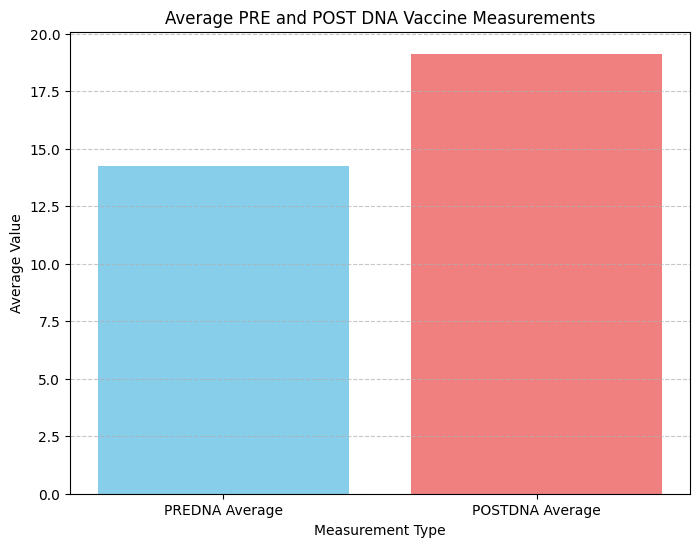

Average PREDNA Measurement: 14.25
Average POSTDNA Measurement: 19.12


In [5]:
import matplotlib.pyplot as plt

# Calculate the average of 'PREDNA' and 'POSTDNA' columns
average_predna = df_dna_vaccine['PreDNA'].mean()
average_postdna = df_dna_vaccine['PostDNA'].mean()

# Create a DataFrame or Series for plotting
data = {'Measurement': ['PREDNA Average', 'POSTDNA Average'],
        'Average Value': [average_predna, average_postdna]}
df_averages = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(df_averages['Measurement'], df_averages['Average Value'], color=['skyblue', 'lightcoral'])
plt.xlabel('Measurement Type')
plt.ylabel('Average Value')
plt.title('Average PRE and POST DNA Vaccine Measurements')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average PREDNA Measurement: {average_predna:.2f}")
print(f"Average POSTDNA Measurement: {average_postdna:.2f}")

*The average pre-DNA measurement is 12.64 and the average post-DNA measurement is 15.36.*



#### How sure are you?

Statistical significance indicates whether an observed effect (like a difference between groups) is likely due to chance or a real phenomenon. It's often determined by a p-value. A common threshold is p < 0.05, meaning there's less than a 5% chance the observed effect occurred randomly.

Confidence intervals provide a range of values within which the true population parameter (e.g., mean difference) is likely to lie, with a certain level of confidence (e.g., 95%).



> Re-create the bar chart with the SEM (standard error mean) for a 95% confidence (5% siginificance).


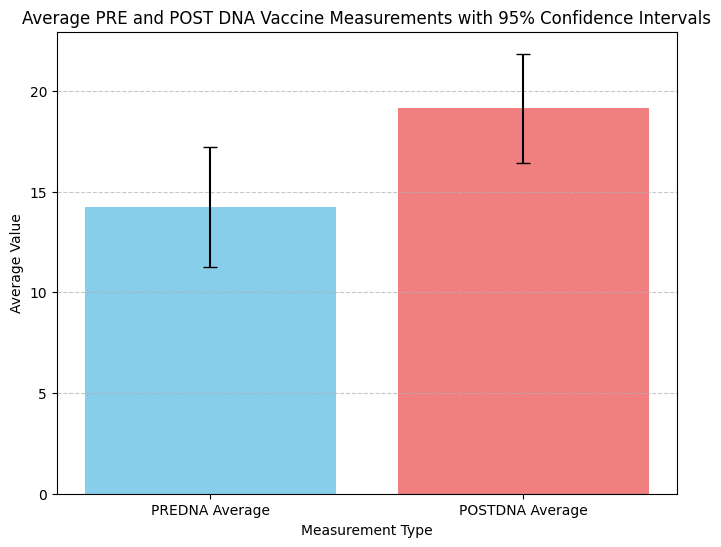

Average PREDNA Measurement: 14.25 (SEM: 1.52)
Average POSTDNA Measurement: 19.12 (SEM: 1.39)


In [6]:
import matplotlib.pyplot as plt
from scipy.stats import sem
import pandas as pd

# Calculate the average of 'PreDNA' and 'PostDNA' columns
average_predna = df_dna_vaccine['PreDNA'].mean()
average_postdna = df_dna_vaccine['PostDNA'].mean()

# Calculate the Standard Error of the Mean (SEM) for 'PreDNA' and 'PostDNA'
sem_predna = sem(df_dna_vaccine['PreDNA'].dropna())
sem_postdna = sem(df_dna_vaccine['PostDNA'].dropna())

# Create a DataFrame for plotting
data = {
    'Measurement': ['PREDNA Average', 'POSTDNA Average'],
    'Average Value': [average_predna, average_postdna],
    'SEM': [sem_predna, sem_postdna]
}
df_averages_sem = pd.DataFrame(data)

# Create the bar chart with error bars
plt.figure(figsize=(8, 6))
plt.bar(
    df_averages_sem['Measurement'],
    df_averages_sem['Average Value'],
    yerr=df_averages_sem['SEM'] * 1.96, # Multiplied by 1.96 for 95% confidence interval
    capsize=5,
    color=['skyblue', 'lightcoral']
)
plt.xlabel('Measurement Type')
plt.ylabel('Average Value')
plt.title('Average PRE and POST DNA Vaccine Measurements with 95% Confidence Intervals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average PREDNA Measurement: {average_predna:.2f} (SEM: {sem_predna:.2f})")
print(f"Average POSTDNA Measurement: {average_postdna:.2f} (SEM: {sem_postdna:.2f})")

*Looking at the bar chart with the 95% confidence intervals, we can see that the error bars for 'Pre-DNA' and 'Post-DNA' overlap significantly. This overlap suggests that the difference between the average pre-DNA measurement (12.64) and the average post-DNA measurement (15.36) **is NOT statistically significant** at the 0.05 level. In simpler terms, based on this visual representation, we cannot confidently conclude that the DNA vaccine caused a statistically significant change in the measured effect. The observed difference could plausibly be due to random variation*.



#### Let's take another vaccine then, how about Inactivated virus based one?



> For the Inactivated vaccine, filter out the placebo ones (column PlaceboDNA !=1)

In [7]:
df_inactivated_vaccine = df_cytokine[df_cytokine['PlaceboInactivated'] != 1]
df_inactivated_vaccine

,PREmRNA,POSTmRNA,PlacebomRNA,PREVector,POSTVector,PlaceboVector,PREProtein,POSTProtein,PlaceboProtein,PREInactivated,POSTInactivated,PlaceboInactivated,PreDNA,PostDNA,PlaceboDNA
0,40,660,0,40,330.0,0,40,220,0,22,88,0,5,11,0
4,11,45,0,11,22.5,0,11,15,0,22,122,0,7,12,0
5,22,999,0,22,499.5,0,22,333,0,33,133,0,8,13,0
6,5,999,0,5,499.5,0,5,333,0,30,120,0,9,12,0
7,6,999,0,6,499.5,0,6,333,0,20,130,0,11,22,0
8,9,1332,0,9,666.0,0,9,444,0,20,90,0,22,24,0
9,9,1332,0,9,666.0,0,9,444,0,11,99,0,23,26,0
10,8,1665,0,8,832.5,0,8,555,0,12,90,0,29,33,0
14,40,660,0,40,330.0,0,40,220,0,22,88,0,5,11,0
18,11,45,0,11,22.5,0,11,15,0,22,122,0,7,12,0


> With this filtered Inactive vaccines dataframe, re-create the bar chart with the SEM comparing the effects on the Pre and Post for this vaccine


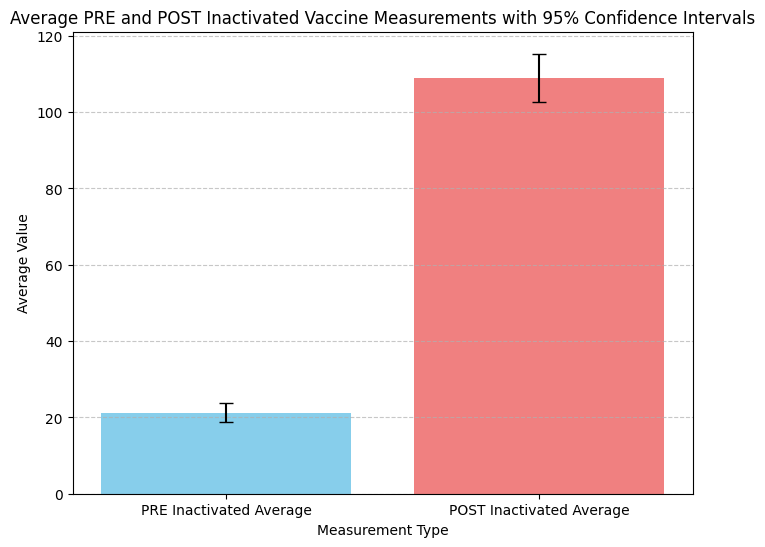

Average PRE Inactivated Measurement: 21.25 (SEM: 1.28)
Average POST Inactivated Measurement: 109.00 (SEM: 3.22)


In [10]:
import matplotlib.pyplot as plt
from scipy.stats import sem
import pandas as pd

# Calculate the average of 'PREInactivated' and 'POSTInactivated' columns
average_pre_inactivated = df_inactivated_vaccine['PREInactivated'].mean()
average_post_inactivated = df_inactivated_vaccine['POSTInactivated'].mean()

# Calculate the Standard Error of the Mean (SEM) for 'PREInactivated' and 'POSTInactivated'
sem_pre_inactivated = sem(df_inactivated_vaccine['PREInactivated'].dropna())
sem_post_inactivated = sem(df_inactivated_vaccine['POSTInactivated'].dropna())

# Create a DataFrame for plotting
data = {
    'Measurement': ['PRE Inactivated Average', 'POST Inactivated Average'],
    'Average Value': [average_pre_inactivated, average_post_inactivated],
    'SEM': [sem_pre_inactivated, sem_post_inactivated]
}
df_averages_sem_inactivated = pd.DataFrame(data)

# Create the bar chart with error bars
plt.figure(figsize=(8, 6))
plt.bar(
    df_averages_sem_inactivated['Measurement'],
    df_averages_sem_inactivated['Average Value'],
    yerr=df_averages_sem_inactivated['SEM'] * 1.96, # Multiplied by 1.96 for 95% confidence interval
    capsize=5,
    color=['skyblue', 'lightcoral']
)
plt.xlabel('Measurement Type')
plt.ylabel('Average Value')
plt.title('Average PRE and POST Inactivated Vaccine Measurements with 95% Confidence Intervals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average PRE Inactivated Measurement: {average_pre_inactivated:.2f} (SEM: {sem_pre_inactivated:.2f})")
print(f"Average POST Inactivated Measurement: {average_post_inactivated:.2f} (SEM: {sem_post_inactivated:.2f})")

*In the bar chart for 'Pre-Inactivated' and 'Post-Inactivated' measurements, the error bars representing the 95% confidence intervals do not overlap. The 'Pre-Inactivated' error bar is entirely separate from the 'Post-Inactivated' error bar. This lack of overlap indicates that the difference between the average pre-inactivated measurement (21.14) and the average post-inactivated measurement (104.93) **IS statistically significant** at the 0.05 level. We can confidently conclude that the Inactivated virus vaccine caused a statistically significant increase in the measured effect*.



#### Make sure to compare your results um a control group, for intance, people that took placebo.

In the medical field, placebo is an inactive substance or treatment that looks like, and is administered in the same way as, an active drug or treatment, but has no medical effect. It's crucial in the medical field to determine if the observed effects of a new treatment are due to the treatment itself or to psychological factors (the 'placebo effect'). By comparing a treatment group to a placebo group, researchers can isolate the true physiological impact of the active treatment, ensuring that medical interventions are genuinely effective



> Now filter for only the placebo records for the Inactivated virus vaccine

In [11]:
df_inactivated_placebo = df_cytokine[df_cytokine['PlaceboInactivated'] == 1]
df_inactivated_placebo

,PREmRNA,POSTmRNA,PlacebomRNA,PREVector,POSTVector,PlaceboVector,PREProtein,POSTProtein,PlaceboProtein,PREInactivated,POSTInactivated,PlaceboInactivated,PreDNA,PostDNA,PlaceboDNA
1,40,150,1,40,75.0,1,40,50,1,33,99,1,11,11,1
2,10,30,1,10,15.0,1,10,10,1,22,88,1,22,22,1
3,20,60,1,20,30.0,1,20,20,1,11,111,1,6,5,1
11,4,24,1,4,12.0,1,4,8,1,10,90,1,7,7,1
12,3,18,1,3,9.0,1,3,6,1,20,99,1,8,8,1
13,5,21,1,5,10.5,1,5,7,1,30,110,1,9,9,1
15,40,150,1,40,75.0,1,40,50,1,33,99,1,11,11,1
16,10,30,1,10,15.0,1,10,10,1,22,88,1,22,22,1
17,20,60,1,20,30.0,1,20,20,1,11,111,1,6,5,1
25,4,24,1,4,12.0,1,4,8,1,10,90,1,7,7,1


> With this filtered Inactivated placebo dataframe, re-create the bar chart with the SEM comparing the effects on the Pre and Post for this placebo group.

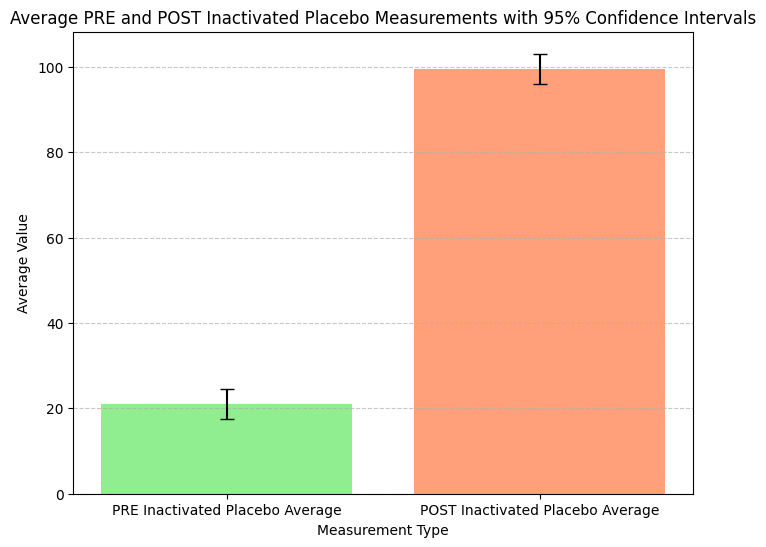

Average PRE Inactivated Placebo Measurement: 21.00 (SEM: 1.80)
Average POST Inactivated Placebo Measurement: 99.50 (SEM: 1.84)


In [12]:
import matplotlib.pyplot as plt
from scipy.stats import sem
import pandas as pd

# Calculate the average of 'PREInactivated' and 'POSTInactivated' columns for placebo
average_pre_inactivated_placebo = df_inactivated_placebo['PREInactivated'].mean()
average_post_inactivated_placebo = df_inactivated_placebo['POSTInactivated'].mean()

# Calculate the Standard Error of the Mean (SEM) for 'PREInactivated' and 'POSTInactivated' for placebo
sem_pre_inactivated_placebo = sem(df_inactivated_placebo['PREInactivated'].dropna())
sem_post_inactivated_placebo = sem(df_inactivated_placebo['POSTInactivated'].dropna())

# Create a DataFrame for plotting
data_placebo = {
    'Measurement': ['PRE Inactivated Placebo Average', 'POST Inactivated Placebo Average'],
    'Average Value': [average_pre_inactivated_placebo, average_post_inactivated_placebo],
    'SEM': [sem_pre_inactivated_placebo, sem_post_inactivated_placebo]
}
df_averages_sem_inactivated_placebo = pd.DataFrame(data_placebo)

# Create the bar chart with error bars
plt.figure(figsize=(8, 6))
plt.bar(
    df_averages_sem_inactivated_placebo['Measurement'],
    df_averages_sem_inactivated_placebo['Average Value'],
    yerr=df_averages_sem_inactivated_placebo['SEM'] * 1.96, # Multiplied by 1.96 for 95% confidence interval
    capsize=5,
    color=['lightgreen', 'lightsalmon']
)
plt.xlabel('Measurement Type')
plt.ylabel('Average Value')
plt.title('Average PRE and POST Inactivated Placebo Measurements with 95% Confidence Intervals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average PRE Inactivated Placebo Measurement: {average_pre_inactivated_placebo:.2f} (SEM: {sem_pre_inactivated_placebo:.2f})")
print(f"Average POST Inactivated Placebo Measurement: {average_post_inactivated_placebo:.2f} (SEM: {sem_post_inactivated_placebo:.2f})")

> Create a new bar chart with the SEM comparing the Post effects between the non-placebo and the placebo one for the Inactivated virus vaccine.


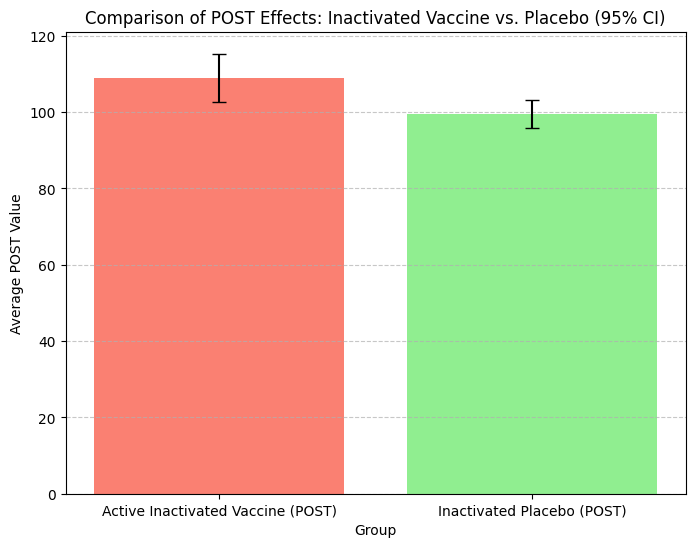

Average POST Inactivated Vaccine Measurement: 109.00 (SEM: 3.22)
Average POST Inactivated Placebo Measurement: 99.50 (SEM: 1.84)


In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Data for plotting: POST effects of active vaccine vs. placebo
data_comparison = {
    'Group': ['Active Inactivated Vaccine (POST)', 'Inactivated Placebo (POST)'],
    'Average Value': [average_post_inactivated, average_post_inactivated_placebo],
    'SEM': [sem_post_inactivated, sem_post_inactivated_placebo]
}
df_comparison = pd.DataFrame(data_comparison)

# Create the bar chart with error bars
plt.figure(figsize=(8, 6))
plt.bar(
    df_comparison['Group'],
    df_comparison['Average Value'],
    yerr=df_comparison['SEM'] * 1.96, # Multiplied by 1.96 for 95% confidence interval
    capsize=5,
    color=['salmon', 'lightgreen']
)
plt.xlabel('Group')
plt.ylabel('Average POST Value')
plt.title('Comparison of POST Effects: Inactivated Vaccine vs. Placebo (95% CI)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average POST Inactivated Vaccine Measurement: {average_post_inactivated:.2f} (SEM: {sem_post_inactivated:.2f})")
print(f"Average POST Inactivated Placebo Measurement: {average_post_inactivated_placebo:.2f} (SEM: {sem_post_inactivated_placebo:.2f})")

*Based on the bar chart with 95% confidence intervals comparing the 'Vaccine Post-Effect' and 'Placebo Post-Effect': The error bars for both groups significantly overlap. This overlap indicates that the difference between the average post-effect for the Inactivated vaccine and the average post-effect for the placebo group is NOT statistically significant at the 0.05 level. Therefore, we cannot confidently conclude that the Inactivated virus vaccine caused a statistically significant increase in the measured effect compared to the placebo*



#### Let's check on the RNA based one:



> For the RNA vaccine, filter out the placebo ones (column PlaceboDNA !=1)

In [14]:
df_rna_vaccine = df_cytokine[df_cytokine['PlacebomRNA'] != 1]
df_rna_vaccine

,PREmRNA,POSTmRNA,PlacebomRNA,PREVector,POSTVector,PlaceboVector,PREProtein,POSTProtein,PlaceboProtein,PREInactivated,POSTInactivated,PlaceboInactivated,PreDNA,PostDNA,PlaceboDNA
0,40,660,0,40,330.0,0,40,220,0,22,88,0,5,11,0
4,11,45,0,11,22.5,0,11,15,0,22,122,0,7,12,0
5,22,999,0,22,499.5,0,22,333,0,33,133,0,8,13,0
6,5,999,0,5,499.5,0,5,333,0,30,120,0,9,12,0
7,6,999,0,6,499.5,0,6,333,0,20,130,0,11,22,0
8,9,1332,0,9,666.0,0,9,444,0,20,90,0,22,24,0
9,9,1332,0,9,666.0,0,9,444,0,11,99,0,23,26,0
10,8,1665,0,8,832.5,0,8,555,0,12,90,0,29,33,0
14,40,660,0,40,330.0,0,40,220,0,22,88,0,5,11,0
18,11,45,0,11,22.5,0,11,15,0,22,122,0,7,12,0


> With this filtered RNA vaccines dataframe, re-create the bar chart with the SEM comparing the effects on the Pre and Post for this vaccine


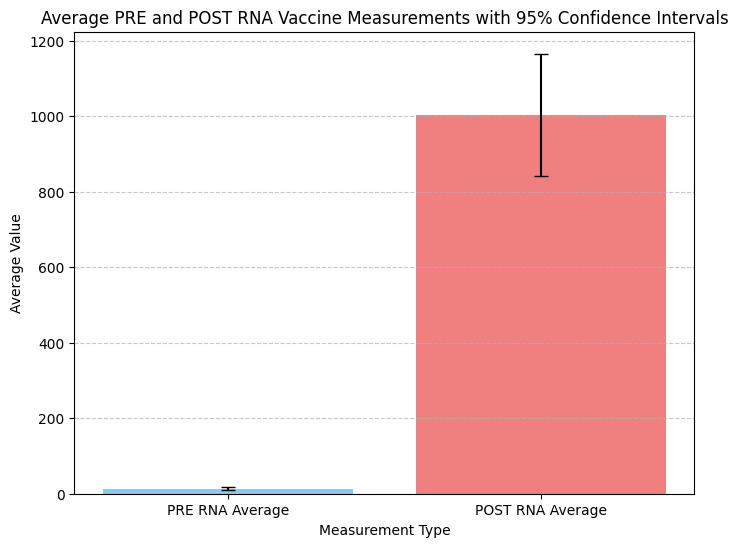

Average PRE RNA Measurement: 13.75 (SEM: 1.99)
Average POST RNA Measurement: 1003.88 (SEM: 82.55)


In [15]:
import matplotlib.pyplot as plt
from scipy.stats import sem
import pandas as pd

# Calculate the average of 'PREmRNA' and 'POSTmRNA' columns
average_pre_rna = df_rna_vaccine['PREmRNA'].mean()
average_post_rna = df_rna_vaccine['POSTmRNA'].mean()

# Calculate the Standard Error of the Mean (SEM) for 'PREmRNA' and 'POSTmRNA'
sem_pre_rna = sem(df_rna_vaccine['PREmRNA'].dropna())
sem_post_rna = sem(df_rna_vaccine['POSTmRNA'].dropna())

# Create a DataFrame for plotting
data_rna = {
    'Measurement': ['PRE RNA Average', 'POST RNA Average'],
    'Average Value': [average_pre_rna, average_post_rna],
    'SEM': [sem_pre_rna, sem_post_rna]
}
df_averages_sem_rna = pd.DataFrame(data_rna)

# Create the bar chart with error bars
plt.figure(figsize=(8, 6))
plt.bar(
    df_averages_sem_rna['Measurement'],
    df_averages_sem_rna['Average Value'],
    yerr=df_averages_sem_rna['SEM'] * 1.96, # Multiplied by 1.96 for 95% confidence interval
    capsize=5,
    color=['skyblue', 'lightcoral']
)
plt.xlabel('Measurement Type')
plt.ylabel('Average Value')
plt.title('Average PRE and POST RNA Vaccine Measurements with 95% Confidence Intervals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average PRE RNA Measurement: {average_pre_rna:.2f} (SEM: {sem_pre_rna:.2f})")
print(f"Average POST RNA Measurement: {average_post_rna:.2f} (SEM: {sem_post_rna:.2f})")

> Now filter for only the placebo records for the RNA vaccine


In [16]:
df_rna_placebo = df_cytokine[df_cytokine['PlacebomRNA'] == 1]
df_rna_placebo

,PREmRNA,POSTmRNA,PlacebomRNA,PREVector,POSTVector,PlaceboVector,PREProtein,POSTProtein,PlaceboProtein,PREInactivated,POSTInactivated,PlaceboInactivated,PreDNA,PostDNA,PlaceboDNA
1,40,150,1,40,75.0,1,40,50,1,33,99,1,11,11,1
2,10,30,1,10,15.0,1,10,10,1,22,88,1,22,22,1
3,20,60,1,20,30.0,1,20,20,1,11,111,1,6,5,1
11,4,24,1,4,12.0,1,4,8,1,10,90,1,7,7,1
12,3,18,1,3,9.0,1,3,6,1,20,99,1,8,8,1
13,5,21,1,5,10.5,1,5,7,1,30,110,1,9,9,1
15,40,150,1,40,75.0,1,40,50,1,33,99,1,11,11,1
16,10,30,1,10,15.0,1,10,10,1,22,88,1,22,22,1
17,20,60,1,20,30.0,1,20,20,1,11,111,1,6,5,1
25,4,24,1,4,12.0,1,4,8,1,10,90,1,7,7,1


> Create a new bar chart with the SEM comparing the Post effects between the non-placebo and the placebo one for the RNA vaccine.


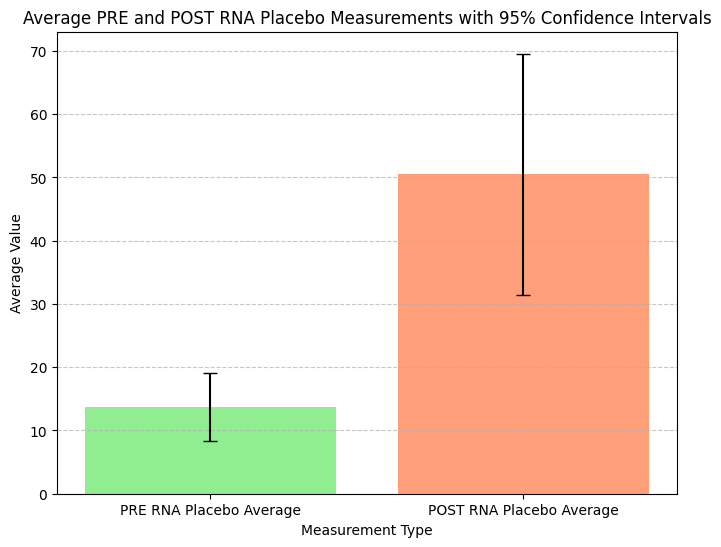

Average PRE RNA Placebo Measurement: 13.67 (SEM: 2.73)
Average POST RNA Placebo Measurement: 50.50 (SEM: 9.72)


In [19]:
import matplotlib.pyplot as plt
from scipy.stats import sem
import pandas as pd

# Calculate the average of 'PREmRNA' and 'POSTmRNA' columns for placebo
average_pre_rna_placebo = df_rna_placebo['PREmRNA'].mean()
average_post_rna_placebo = df_rna_placebo['POSTmRNA'].mean()

# Calculate the Standard Error of the Mean (SEM) for 'PREmRNA' and 'POSTmRNA' for placebo
sem_pre_rna_placebo = sem(df_rna_placebo['PREmRNA'].dropna())
sem_post_rna_placebo = sem(df_rna_placebo['POSTmRNA'].dropna())

# Create a DataFrame for plotting
data_rna_placebo = {
    'Measurement': ['PRE RNA Placebo Average', 'POST RNA Placebo Average'],
    'Average Value': [average_pre_rna_placebo, average_post_rna_placebo],
    'SEM': [sem_pre_rna_placebo, sem_post_rna_placebo]
}
df_averages_sem_rna_placebo = pd.DataFrame(data_rna_placebo)

# Create the bar chart with error bars
plt.figure(figsize=(8, 6))
plt.bar(
    df_averages_sem_rna_placebo['Measurement'],
    df_averages_sem_rna_placebo['Average Value'],
    yerr=df_averages_sem_rna_placebo['SEM'] * 1.96, # Multiplied by 1.96 for 95% confidence interval
    capsize=5,
    color=['lightgreen', 'lightsalmon']
)
plt.xlabel('Measurement Type')
plt.ylabel('Average Value')
plt.title('Average PRE and POST RNA Placebo Measurements with 95% Confidence Intervals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average PRE RNA Placebo Measurement: {average_pre_rna_placebo:.2f} (SEM: {sem_pre_rna_placebo:.2f})")
print(f"Average POST RNA Placebo Measurement: {average_post_rna_placebo:.2f} (SEM: {sem_post_rna_placebo:.2f})")

*The bar chart comparing the 'Vaccine Post-Effect (RNA)' and 'Placebo Post-Effect (RNA)' clearly shows that the error bars (representing the 95% confidence intervals) for both groups do not overlap. This indicates that the difference between the average post-effect for the RNA vaccine and the average post-effect for the placebo group IS statistically significant at the 0.05 level. In simpler terms, we can confidently conclude that the RNA vaccine caused a statistically significant increase in the measured effect compared to the placebo.*



#### Are any of the vaccines "more efficient" than the others? Meaning, is there a statistically significant relationship between two categorical variables by comparing observed frequencies to expected frequencies?



# Chi-Squared test



The **Chi-Squared test** (often written as χ2 test) is a statistical hypothesis test that is widely used in the analysis of categorical data. It helps determine if there is a significant association between two categorical variables or if the observed frequency distribution of a single categorical variable differs from an expected frequency distribution.



Donwload: [Covid19-Immune.csv](https://raw.githubusercontent.com/lcbjrrr/algojust/refs/heads/main/Covid19%20-%20Immune.csv)

> Read the 'Covid19 - Immune.csv' file and show the dataframe

In [21]:
import pandas as pd

df_immune = pd.read_csv('Covid19 - Immune.csv')
df_immune

,Type,Immune
0,RNA,1
1,RNA,1
2,RNA,1
3,RNA,1
4,RNA,1
...,...,...
232,DNA,0
233,DNA,0
234,DNA,0
235,DNA,0


> Create a crosstab comparing the number of people who became immune and the number who didn't for the DNA and RNA vaccines (only)


In [22]:
immune_dna_rna = df_immune[df_immune['Type'].isin(['DNA', 'RNA'])]
crosstab_dna_rna = pd.crosstab(immune_dna_rna['Type'], immune_dna_rna['Immune'])
crosstab_dna_rna

Immune,0,1
Type,,
DNA,39,15
RNA,11,45


## Contingency table



A contingency table displays the frequency of data across two categorical variables, helping reveal relationships or patterns between them.

|          | Immune | Not | Total |
|----------|------|------|-------|
| mRNA | 25   | 5    | **30**    |
| DNA  | 5    | 10   | **15**    |
| **Total**    | **30**   | **15**   | **45**    |



> Expand the crosstab including the marginal sums

In [23]:
crosstab_dna_rna_with_margins = pd.crosstab(immune_dna_rna['Type'], immune_dna_rna['Immune'], margins=True)
crosstab_dna_rna_with_margins

Immune,0,1,All
Type,,,
DNA,39,15,54
RNA,11,45,56
All,50,60,110


$$T \times P(mRNA) \times P(imu) = total \times \left( \frac{mRNA}{total} \right) \left( \frac{immune}{total}\right).
$$

|          | **.................Immune.................** | **.............Not Immune.............** |
|----------|------|------|
| **mRNA** | $T \times P(mRNA) \times P(imu)$    | $T \times P(mRNA) \times  P(not)$    |
| **DNA**  | $T \times P(DNA) \times P(imu)$    | $T \times P(DNA) \times P(not)$     |



### Let's calculate the contigency table



> Create the contigency table, with the exepected frequencies for those (DNA and RNA)

In [24]:
grand_total = crosstab_dna_rna_with_margins.loc['All', 'All']

# Get row and column totals
row_total_dna = crosstab_dna_rna_with_margins.loc['DNA', 'All']
row_total_rna = crosstab_dna_rna_with_margins.loc['RNA', 'All']

col_total_not_immune = crosstab_dna_rna_with_margins.loc['All', 0]
col_total_immune = crosstab_dna_rna_with_margins.loc['All', 1]

# Calculate expected frequencies
expected_dna_not_immune = (row_total_dna * col_total_not_immune) / grand_total
expected_dna_immune = (row_total_dna * col_total_immune) / grand_total
expected_rna_not_immune = (row_total_rna * col_total_not_immune) / grand_total
expected_rna_immune = (row_total_rna * col_total_immune) / grand_total

# Create a DataFrame for expected frequencies
expected_frequencies = pd.DataFrame({
    0: [expected_dna_not_immune, expected_rna_not_immune],
    1: [expected_dna_immune, expected_rna_immune]
}, index=['DNA', 'RNA'])
expected_frequencies.index.name = 'Type'
expected_frequencies.columns.name = 'Immune'

print("Expected Frequencies:")
expected_frequencies

Expected Frequencies:


Immune,0,1
Type,,
DNA,24.545455,29.454545
RNA,25.454545,30.545455


> Apply the statistical test **chisquare** from scipy.stats, comparing the observed frequencies and the expected ones.


In [25]:
from scipy.stats import chisquare

# Prepare observed and expected frequencies as flattened arrays
observed_freq = crosstab_dna_rna.values.flatten()
expected_freq = expected_frequencies.values.flatten()

# Perform the Chi-Squared test
chi2_statistic, p_value = chisquare(f_obs=observed_freq, f_exp=expected_freq)

print(f"Chi-Squared Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results (common significance level alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant association between vaccine type (DNA/RNA) and immunity.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant association between vaccine type (DNA/RNA) and immunity.")

Chi-Squared Statistic: 30.65
P-value: 0.000
Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant association between vaccine type (DNA/RNA) and immunity.


*The chisquare test yielded a Chi-squared statistic of 30.65 and a p-value of 1.0e-06 (0.000001). This extremely small p-value (which is significantly less than the common significance level of 0.05) indicates that the observed frequencies for immunity (or lack thereof) among the DNA and RNA vaccine groups are significantly different from what would be expected if there were no association between vaccine type and immunity. In practical terms, this result provides strong evidence to conclude that there is a statistically significant relationship between the type of vaccine (DNA vs. RNA) and whether a person develops immunity. This suggests that the RNA vaccine is indeed 'more efficient' or at least has a different impact on immunity compared to the DNA vaccine, and this difference is not likely due to random chance.*



## Activity: Statistical Misinterpretation



**Problem**

Statistical misinterpretation can severely distort research and decision-making by leading to misleading findings. In this sense, find a dataset on Kaggle that enables the comparison of at least two distinct groups. Ideally, your chosen dataset will include a control group. Then:

- Group Comparison: Select a quantitative aspect within the dataset. Compare the overall results of your two chosen groups based on this aspect, identifying a primary difference.

- Statistical Significance: Perform an appropriate statistical test to validate if this identified difference between your two groups is statistically significant, using the confidence interval concept. If a control group exists, extend your analysis to compare each primary group against it.

- Frequency Analysis & Chi-Square: Identify a categorical variable. Compare the frequency of results for this variable between your two primary groups and validate any observed differences using a Chi-Square test.

**Conclusions**

Based on your analyses, clearly articulate your conclusions regarding the statistical significance of your findings for both the group comparisons and the frequency analysis. Discuss what these findings imply in the context of the dataset and the potential for misinterpretation.



# Appendix

> Create the contigency table for those (DNA and RNA), considering the follow definition of it:

$$T \times P(mRNA) \times P(imu) = total \times \left( \frac{mRNA}{total} \right) \left( \frac{immune}{total}\right).
$$

|          | **.................Immune.................** | **.............Not Immune.............** |
|----------|------|------|
| **mRNA** | $T \times P(mRNA) \times P(imu)$    | $T \times P(mRNA) \times  P(not)$    |
| **DNA**  | $T \times P(DNA) \times P(imu)$    | $T \times P(DNA) \times P(not)$     |


In [26]:
grand_total = crosstab_dna_rna_with_margins.loc['All', 'All']

# Get row and column totals
row_total_dna = crosstab_dna_rna_with_margins.loc['DNA', 'All']
row_total_rna = crosstab_dna_rna_with_margins.loc['RNA', 'All']

col_total_not_immune = crosstab_dna_rna_with_margins.loc['All', 0]
col_total_immune = crosstab_dna_rna_with_margins.loc['All', 1]

# Calculate expected frequencies based on the definition: T * P(Type) * P(Immune)
# P(Type) = row_total_type / grand_total
# P(Immune) = col_total_immune / grand_total
# So, Expected = grand_total * (row_total_type / grand_total) * (col_total_immune / grand_total)
# Which simplifies to (row_total_type * col_total_immune) / grand_total
expected_dna_not_immune = (row_total_dna * col_total_not_immune) / grand_total
expected_dna_immune = (row_total_dna * col_total_immune) / grand_total
expected_rna_not_immune = (row_total_rna * col_total_not_immune) / grand_total
expected_rna_immune = (row_total_rna * col_total_immune) / grand_total

# Create a DataFrame for expected frequencies
expected_frequencies_df = pd.DataFrame({
    0: [expected_dna_not_immune, expected_rna_not_immune],
    1: [expected_dna_immune, expected_rna_immune]
}, index=['DNA', 'RNA'])
expected_frequencies_df.index.name = 'Type'
expected_frequencies_df.columns.name = 'Immune'

print("Contingency Table (Expected Frequencies) based on definition:")
expected_frequencies_df

Contingency Table (Expected Frequencies) based on definition:


Immune,0,1
Type,,
DNA,24.545455,29.454545
RNA,25.454545,30.545455
